# TF-IDF Test Evaluation and Error Analysis

In this notebook, we evaluate the saved TF-IDF + PyTorch
logistic-regression model on the official IMDb test set.

Goals:

1. Load the cleaned IMDb test set.
2. Load the fitted TF-IDF vectorizer.
3. Load the trained PyTorch model.
4. Generate predictions for every test review.
5. Calculate final test metrics.
6. Analyze the model's mistakes.

Important:

The test set is used only for final evaluation.
We do not train the model or tune hyperparameters using test results.
In this notebook, we evaluate the saved TF-IDF + PyTorch
logistic-regression model on the official IMDb test set.

Goals:

1. Load the cleaned IMDb test set.
2. Load the fitted TF-IDF vectorizer.
3. Load the trained PyTorch model.
4. Generate predictions for every test review.
5. Calculate final test metrics.
6. Analyze the model's mistakes.

Important:

The test set is used only for final evaluation.
We do not train the model or tune hyperparameters using test results.


In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from datasets import load_from_disk

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

In [2]:
CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT),
    )

print("Current directory:", CURRENT_DIR)
print("Project root:", PROJECT_ROOT)

Current directory: D:\app\ai\Sentiment Analysis Traditional ML vs Transformers\notebooks
Project root: D:\app\ai\Sentiment Analysis Traditional ML vs Transformers


In [3]:
DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "imdb_clean_splits"
)

MODEL_DIR = PROJECT_ROOT / "models"

REPORT_DIR = (
    PROJECT_ROOT
    / "reports"
    / "baseline"
    / "test_evaluation"
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("Data path:", DATA_PATH)
print("Model directory:", MODEL_DIR)
print("Report directory:", REPORT_DIR)

Data path: D:\app\ai\Sentiment Analysis Traditional ML vs Transformers\data\processed\imdb_clean_splits
Model directory: D:\app\ai\Sentiment Analysis Traditional ML vs Transformers\models
Report directory: D:\app\ai\Sentiment Analysis Traditional ML vs Transformers\reports\baseline\test_evaluation


## 3. Import reusable prediction code

Instead of defining the text-cleaning function and model architecture
again, we import them from `predict_tfidf.py`.

This keeps training, prediction, and evaluation consistent.

In [4]:
try:
    from src.predict_tfidf import (
        clean_text_for_model,
        load_artifacts,
    )
except ModuleNotFoundError:
    from predict_tfidf import (
        clean_text_for_model,
        load_artifacts,
    )

## 4. Load the test set and saved artifacts

In this section, we load:

- the official IMDb test set
- the fitted TF-IDF vectorizer
- the trained PyTorch model

No training happens in this notebook.

In [5]:
dataset = load_from_disk(
    str(DATA_PATH)
)

test_df = (
    dataset["test"]
    .to_pandas()[["text", "label"]]
    .copy()
)

label_names = (
    dataset["test"]
    .features["label"]
    .names
)

model, vectorizer, device = load_artifacts(
    model_dir=MODEL_DIR
)

print(f"Test rows: {len(test_df):,}")
print("Label names:", label_names)
print("Device:", device)
print(
    "Vectorizer features:",
    len(vectorizer.get_feature_names_out()),
)

Test rows: 25,000
Label names: ['neg', 'pos']
Device: cuda
Vectorizer features: 20000


## 5. Clean and vectorize the test set

We apply the same text-cleaning function used during training.

The saved vectorizer only transforms the test text.
It does not learn a new vocabulary or new IDF values.

In [6]:
test_texts = (
    test_df["text"]
    .map(clean_text_for_model)
    .tolist()
)

y_test = test_df["label"].to_numpy(
    dtype=np.int64
)

In [7]:
X_test = vectorizer.transform(
    test_texts
)

print("X_test shape:", X_test.shape)
print("X_test type:", type(X_test).__name__)
print("Non-zero values:", f"{X_test.nnz:,}")

X_test shape: (25000, 20000)
X_test type: csr_matrix
Non-zero values: 3,172,287


In [8]:
number_of_vectorizer_features = len(
    vectorizer.get_feature_names_out()
)

assert X_test.shape[0] == len(test_df)

assert X_test.shape[1] == (
    number_of_vectorizer_features
)

assert len(y_test) == len(test_df)

assert len(test_texts) == len(test_df)

print("All test-data checks passed.")

All test-data checks passed.


## 6. Run batched inference

The TF-IDF test matrix remains sparse.

We select a small group of rows, temporarily convert only that group
to a dense tensor, run the model, and repeat until every test review
has a prediction.

In [9]:
INFERENCE_BATCH_SIZE = 512

print(
    "Inference batch size:",
    INFERENCE_BATCH_SIZE,
)

Inference batch size: 512


In [10]:
def predict_in_batches(
    model: torch.nn.Module,
    sparse_features,
    device: torch.device,
    batch_size: int = 512,
) -> np.ndarray:
    """
    Predict positive-class probabilities for a sparse feature matrix.

    Only one batch is converted to a dense array at a time.
    """

    if batch_size <= 0:
        raise ValueError(
            "batch_size must be greater than zero."
        )

    number_of_examples = sparse_features.shape[0]

    probability_batches = []

    model.eval()

    with torch.inference_mode():
        for start_index in range(
            0,
            number_of_examples,
            batch_size,
        ):
            end_index = min(
                start_index + batch_size,
                number_of_examples,
            )

            sparse_batch = sparse_features[
                start_index:end_index
            ]

            dense_batch = (
                sparse_batch
                .toarray()
                .astype(
                    np.float32,
                    copy=False,
                )
            )

            feature_tensor = torch.from_numpy(
                dense_batch
            ).to(device)

            logits = model(
                feature_tensor
            )

            positive_probabilities = torch.sigmoid(
                logits
            )

            probability_batches.append(
                positive_probabilities
                .cpu()
                .numpy()
            )

    return np.concatenate(
        probability_batches
    )

### Generate test predictions

We measure the total inference time and convert the positive-class
probabilities into predicted class IDs using a threshold of 0.5.

In [11]:
inference_start_time = time.perf_counter()

test_positive_probabilities = predict_in_batches(
    model=model,
    sparse_features=X_test,
    device=device,
    batch_size=INFERENCE_BATCH_SIZE,
)

inference_seconds = (
    time.perf_counter()
    - inference_start_time
)

test_predictions = (
    test_positive_probabilities >= 0.5
).astype(np.int64)

test_negative_probabilities = (
    1.0 - test_positive_probabilities
)

print(
    "Inference time:",
    f"{inference_seconds:.2f} seconds",
)

print(
    "Number of predictions:",
    f"{len(test_predictions):,}",
)

Inference time: 1.30 seconds
Number of predictions: 25,000


In [12]:
assert test_positive_probabilities.shape == (
    len(test_df),
)

assert test_predictions.shape == (
    len(test_df),
)

assert np.all(
    test_positive_probabilities >= 0.0
)

assert np.all(
    test_positive_probabilities <= 1.0
)

assert set(
    np.unique(test_predictions)
).issubset({0, 1})

print("All inference checks passed.")

All inference checks passed.


In [13]:
prediction_preview = pd.DataFrame(
    {
        "actual_label_id": y_test[:10],
        "predicted_label_id": (
            test_predictions[:10]
        ),
        "positive_probability": (
            test_positive_probabilities[:10]
        ),
    }
)

prediction_preview[
    "actual_label"
] = prediction_preview[
    "actual_label_id"
].map(
    {
        0: label_names[0],
        1: label_names[1],
    }
)

prediction_preview[
    "predicted_label"
] = prediction_preview[
    "predicted_label_id"
].map(
    {
        0: label_names[0],
        1: label_names[1],
    }
)

prediction_preview

,actual_label_id,predicted_label_id,positive_probability,actual_label,predicted_label
0,0,0,0.308319,neg,neg
1,0,0,0.381565,neg,neg
2,0,0,0.347738,neg,neg
3,0,0,0.417665,neg,neg
4,0,1,0.502756,neg,pos
5,0,0,0.324278,neg,neg
6,0,0,0.495232,neg,neg
7,0,0,0.301296,neg,neg
8,0,0,0.247840,neg,neg
9,0,0,0.154898,neg,neg


## 7. Calculate final test metrics

We compare the predicted labels with the true test labels.

The main metrics are:

- Accuracy
- Precision
- Recall
- F1
- Macro F1
- Inference speed

In [14]:
test_accuracy = accuracy_score(
    y_test,
    test_predictions,
)

test_precision = precision_score(
    y_test,
    test_predictions,
    pos_label=1,
    zero_division=0,
)

test_recall = recall_score(
    y_test,
    test_predictions,
    pos_label=1,
    zero_division=0,
)

test_f1 = f1_score(
    y_test,
    test_predictions,
    pos_label=1,
    zero_division=0,
)

test_macro_f1 = f1_score(
    y_test,
    test_predictions,
    average="macro",
    zero_division=0,
)

reviews_per_second = (
    len(test_df)
    / inference_seconds
)

print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1: {test_f1:.4f}")
print(f"Macro F1: {test_macro_f1:.4f}")

print(
    "Reviews per second:",
    f"{reviews_per_second:,.2f}",
)

Accuracy: 0.8575
Precision: 0.8563
Recall: 0.8591
F1: 0.8577
Macro F1: 0.8575
Reviews per second: 19,249.71


## 8. Classification report

The classification report shows precision, recall, F1, and support
for each class separately.

In [15]:
report_dict = classification_report(
    y_test,
    test_predictions,
    labels=[0, 1],
    target_names=label_names,
    output_dict=True,
    zero_division=0,
)

classification_report_df = (
    pd.DataFrame(report_dict)
    .transpose()
)

classification_report_df

,precision,recall,f1-score,support
neg,0.858656,0.85584,0.857246,12500.00000
pos,0.856311,0.85912,0.857713,12500.00000
accuracy,0.857480,0.85748,0.857480,0.85748
macro avg,0.857484,0.85748,0.857480,25000.00000
weighted avg,0.857484,0.85748,0.857480,25000.00000


## 9. Confusion matrix

The confusion matrix shows the exact types of correct and incorrect
predictions.

```text
                    Predicted
                 Negative  Positive

Actual Negative      TN        FP
Actual Positive      FN        TP

In [17]:
test_confusion_matrix = confusion_matrix(
    y_test,
    test_predictions,
    labels=[0, 1],
)

confusion_matrix_df = pd.DataFrame(
    test_confusion_matrix,
    index=[
        "actual_neg",
        "actual_pos",
    ],
    columns=[
        "predicted_neg",
        "predicted_pos",
    ],
)

confusion_matrix_df

,predicted_neg,predicted_pos
actual_neg,10698,1802
actual_pos,1761,10739


In [18]:
true_negative, false_positive, false_negative, true_positive = (
    test_confusion_matrix.ravel()
)

print("True Negative:", f"{true_negative:,}")
print("False Positive:", f"{false_positive:,}")
print("False Negative:", f"{false_negative:,}")
print("True Positive:", f"{true_positive:,}")

True Negative: 10,698
False Positive: 1,802
False Negative: 1,761
True Positive: 10,739


In [19]:
manual_accuracy = (
    true_negative + true_positive
) / len(y_test)

manual_precision = (
    true_positive
    / (true_positive + false_positive)
)

manual_recall = (
    true_positive
    / (true_positive + false_negative)
)

print(
    "Manual accuracy matches:",
    np.isclose(
        manual_accuracy,
        test_accuracy,
    ),
)

print(
    "Manual precision matches:",
    np.isclose(
        manual_precision,
        test_precision,
    ),
)

print(
    "Manual recall matches:",
    np.isclose(
        manual_recall,
        test_recall,
    ),
)

Manual accuracy matches: True
Manual precision matches: True
Manual recall matches: True


In [20]:
from sklearn.metrics import ConfusionMatrixDisplay

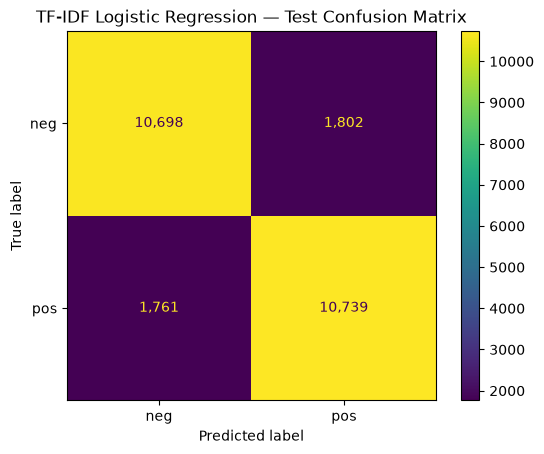

In [21]:
confusion_display = ConfusionMatrixDisplay(
    confusion_matrix=test_confusion_matrix,
    display_labels=label_names,
)

confusion_display.plot(
    values_format=",d",
)

plt.title(
    "TF-IDF Logistic Regression — Test Confusion Matrix"
)

plt.show()

## 10. Build a prediction-results table

We combine the original review text, true labels, predictions,
and probabilities into one DataFrame.

This table will be the foundation for error analysis.

In [22]:
results_df = test_df.copy()

results_df[
    "actual_label_id"
] = y_test

results_df[
    "predicted_label_id"
] = test_predictions

results_df[
    "positive_probability"
] = test_positive_probabilities

results_df[
    "negative_probability"
] = test_negative_probabilities

In [23]:
label_id_to_name = {
    0: label_names[0],
    1: label_names[1],
}

results_df[
    "actual_label"
] = results_df[
    "actual_label_id"
].map(
    label_id_to_name
)

results_df[
    "predicted_label"
] = results_df[
    "predicted_label_id"
].map(
    label_id_to_name
)

In [24]:
results_df[
    "is_correct"
] = (
    results_df["actual_label_id"]
    == results_df["predicted_label_id"]
)

### Prediction confidence

A probability close to 0.5 means the model is uncertain.

A probability close to 0 or 1 means the model is more confident.

In [25]:
results_df[
    "confidence"
] = np.maximum(
    results_df[
        "positive_probability"
    ],
    results_df[
        "negative_probability"
    ],
)

In [26]:
def classify_prediction(
    actual_label_id: int,
    predicted_label_id: int,
) -> str:
    if (
        actual_label_id == 0
        and predicted_label_id == 0
    ):
        return "true_negative"

    if (
        actual_label_id == 0
        and predicted_label_id == 1
    ):
        return "false_positive"

    if (
        actual_label_id == 1
        and predicted_label_id == 0
    ):
        return "false_negative"

    return "true_positive"


results_df[
    "prediction_type"
] = results_df.apply(
    lambda row: classify_prediction(
        row["actual_label_id"],
        row["predicted_label_id"],
    ),
    axis=1,
)

In [27]:
prediction_type_counts = (
    results_df[
        "prediction_type"
    ]
    .value_counts()
)

prediction_type_counts

prediction_type
true_positive     10739
true_negative     10698
false_positive     1802
false_negative     1761
Name: count, dtype: int64

In [28]:
assert (
    prediction_type_counts[
        "true_negative"
    ]
    == true_negative
)

assert (
    prediction_type_counts[
        "false_positive"
    ]
    == false_positive
)

assert (
    prediction_type_counts[
        "false_negative"
    ]
    == false_negative
)

assert (
    prediction_type_counts[
        "true_positive"
    ]
    == true_positive
)

print(
    "Prediction-type counts match "
    "the confusion matrix."
)

Prediction-type counts match the confusion matrix.


## 11. Analyze incorrect predictions

We first isolate every incorrect prediction and then separate
false positives from false negatives.

In [29]:
errors_df = (
    results_df[
        ~results_df["is_correct"]
    ]
    .copy()
)

print(
    "Total errors:",
    f"{len(errors_df):,}",
)

print(
    "Error rate:",
    f"{len(errors_df) / len(results_df):.2%}",
)

Total errors: 3,563
Error rate: 14.25%


In [30]:
false_positives_df = (
    results_df[
        results_df[
            "prediction_type"
        ] == "false_positive"
    ]
    .copy()
)

print(
    "False positives:",
    f"{len(false_positives_df):,}",
)

False positives: 1,802


In [31]:
false_negatives_df = (
    results_df[
        results_df[
            "prediction_type"
        ] == "false_negative"
    ]
    .copy()
)

print(
    "False negatives:",
    f"{len(false_negatives_df):,}",
)

False negatives: 1,761


In [32]:
most_confident_false_positives = (
    false_positives_df
    .sort_values(
        by="confidence",
        ascending=False,
    )
    .head(10)
)

most_confident_false_positives[
    [
        "text",
        "actual_label",
        "predicted_label",
        "positive_probability",
        "confidence",
    ]
]

,text,actual_label,predicted_label,positive_probability,confidence
6245,Mickey Rourke hunts Diane Lane in Elmore Leona...,neg,pos,0.807898,0.807898
11234,I have recently found this film on one of my h...,neg,pos,0.801783,0.801783
4118,This is definitely one of the best Kung fu mov...,neg,pos,0.784443,0.784443
6844,"Voor een verloren soldaat , for a lost soldier...",neg,pos,0.773850,0.773850
5820,I saw Winnie's Heffalump a couple of days ago....,neg,pos,0.771251,0.771251
3553,"This film has the language, the style and the ...",neg,pos,0.763537,0.763537
9764,Disappointing film with Walter Pidgeon as a hu...,neg,pos,0.756401,0.756401
805,"""The Duke"" is a film based in the heart of the...",neg,pos,0.753406,0.753406
6663,"In the mountains of Japan, forlorn young artis...",neg,pos,0.749912,0.749912
3689,The EMPEROR'S NEW GROOVE cast returns for Disn...,neg,pos,0.749178,0.749178


In [33]:
most_confident_false_negatives = (
    false_negatives_df
    .sort_values(
        by="confidence",
        ascending=False,
    )
    .head(10)
)

most_confident_false_negatives[
    [
        "text",
        "actual_label",
        "predicted_label",
        "positive_probability",
        "confidence",
    ]
]

,text,actual_label,predicted_label,positive_probability,confidence
15074,When the movie first started I thought cheesy....,pos,neg,0.193680,0.806320
17868,My sisters and my cousin(female) forced me to ...,pos,neg,0.203260,0.796740
15208,**SPOILERS AHEAD**<br /><br />It is really unf...,pos,neg,0.205311,0.794689
22135,First off I want to say most of the people who...,pos,neg,0.223295,0.776705
13811,i was having a horrid day but this movie grabb...,pos,neg,0.229352,0.770648
13933,"Un Gatto nel Cervello, or Nightmare Concert as...",pos,neg,0.229747,0.770253
14565,"Yes, indeed we have a winner- a winner in best...",pos,neg,0.234876,0.765124
17992,What is your freaking problem? Do you have not...,pos,neg,0.235432,0.764568
13474,The Japanese have probably the most sadistic m...,pos,neg,0.245032,0.754968
23957,The 80's is largely considered the decade in w...,pos,neg,0.248801,0.751199


In [34]:
errors_near_boundary = (
    errors_df
    .assign(
        distance_from_threshold=lambda df:
        np.abs(
            df[
                "positive_probability"
            ] - 0.5
        )
    )
    .sort_values(
        by="distance_from_threshold",
        ascending=True,
    )
    .head(10)
)

errors_near_boundary[
    [
        "text",
        "actual_label",
        "predicted_label",
        "positive_probability",
        "distance_from_threshold",
    ]
]

,text,actual_label,predicted_label,positive_probability,distance_from_threshold
19463,"If you're a science fiction fan, and you've on...",pos,neg,0.499986,0.000014
8980,Is there anything else on earth to be more ent...,neg,pos,0.500014,0.000014
19783,You cannot be seeing the same movie if you did...,pos,neg,0.499976,0.000024
17694,My Santa Lucia Choir was chosen to be in this ...,pos,neg,0.499969,0.000031
11693,Jud Nelson is an aspiring actor who becomes in...,neg,pos,0.500058,0.000058
9392,I was told about this film from a friend who s...,neg,pos,0.500058,0.000058
14355,As a non-theist Im not going to comment on the...,pos,neg,0.499910,0.000090
6082,I find myself alarmed that people are not so c...,neg,pos,0.500094,0.000094
6161,CHEERLEADER MASSACRE (2003)<br /><br />starrin...,neg,pos,0.500101,0.000101
21839,"Um, hello.. Rainbow Brite.. the name alone is ...",pos,neg,0.499875,0.000125


In [35]:
results_df[
    "word_count"
] = (
    results_df["text"]
    .str.split()
    .str.len()
)

In [36]:
length_analysis = (
    results_df
    .groupby(
        "is_correct"
    )["word_count"]
    .agg(
        [
            "count",
            "mean",
            "median",
            "min",
            "max",
        ]
    )
)

length_analysis

,count,mean,median,min,max
is_correct,,,,,
False,3563,230.326130,176.0,8,2108
True,21437,228.227597,171.0,4,2278


## 12. Analyze errors by review length

We group reviews into length ranges and calculate the error rate
inside each group.

This helps us check whether very short or very long reviews are
harder for the model.

In [37]:
length_bins = [
    0,
    50,
    100,
    200,
    400,
    800,
    np.inf,
]

length_labels = [
    "1-50",
    "51-100",
    "101-200",
    "201-400",
    "401-800",
    "800+",
]

results_df[
    "length_group"
] = pd.cut(
    results_df["word_count"],
    bins=length_bins,
    labels=length_labels,
    include_lowest=True,
)

In [38]:
length_group_analysis = (
    results_df
    .groupby(
        "length_group",
        observed=False,
    )
    .agg(
        review_count=(
            "is_correct",
            "size",
        ),
        correct_count=(
            "is_correct",
            "sum",
        ),
        average_confidence=(
            "confidence",
            "mean",
        ),
        average_positive_probability=(
            "positive_probability",
            "mean",
        ),
    )
    .reset_index()
)

In [39]:
length_group_analysis[
    "accuracy"
] = (
    length_group_analysis[
        "correct_count"
    ]
    / length_group_analysis[
        "review_count"
    ]
)

length_group_analysis[
    "error_rate"
] = (
    1.0
    - length_group_analysis[
        "accuracy"
    ]
)

length_group_analysis

,length_group,review_count,correct_count,average_confidence,average_positive_probability,accuracy,error_rate
0,1-50,657,582,0.640117,0.516595,0.885845,0.114155
1,51-100,2482,2159,0.635499,0.507404,0.869863,0.130137
2,101-200,11783,10103,0.641557,0.490647,0.857422,0.142578
3,201-400,6947,5905,0.648903,0.488541,0.850007,0.149993
4,401-800,2713,2320,0.658490,0.504590,0.855142,0.144858
5,800+,418,368,0.670214,0.506325,0.880383,0.119617


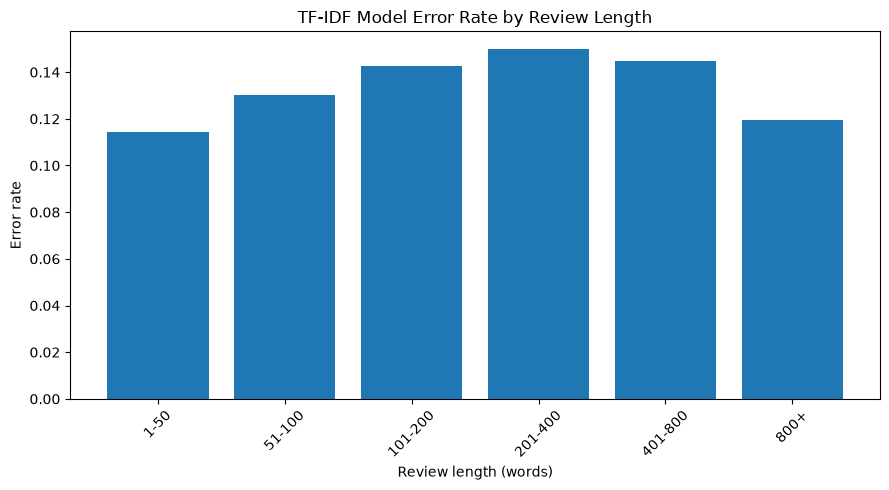

In [40]:
plt.figure(
    figsize=(9, 5)
)

plt.bar(
    length_group_analysis[
        "length_group"
    ].astype(str),
    length_group_analysis[
        "error_rate"
    ],
)

plt.xlabel(
    "Review length (words)"
)

plt.ylabel(
    "Error rate"
)

plt.title(
    "TF-IDF Model Error Rate by Review Length"
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()

## 13. Interpret the learned model weights

Because the model is linear, every TF-IDF feature has one learned
weight.

Positive weights push predictions toward positive sentiment.

Negative weights push predictions toward negative sentiment.

In [41]:
feature_names = (
    vectorizer
    .get_feature_names_out()
)

print(
    "Number of feature names:",
    len(feature_names),
)

print(
    "First 20 features:"
)

print(
    feature_names[:20]
)

Number of feature names: 20000
First 20 features:
['00' '000' '007' '01' '02' '05' '06' '07' '10' '100' '1000' '101' '102'
 '105' '10th' '11' '110' '11th' '12' '120']


In [42]:
model_weights = (
    model.linear.weight
    .detach()
    .cpu()
    .numpy()
    .reshape(-1)
)

model_bias = (
    model.linear.bias
    .detach()
    .cpu()
    .item()
)

print(
    "Number of weights:",
    len(model_weights),
)

print(
    "Bias:",
    model_bias,
)

Number of weights: 20000
Bias: 0.12872228026390076


In [43]:
assert (
    len(feature_names)
    == len(model_weights)
)

print(
    "Feature names and model weights match."
)

Feature names and model weights match.


In [45]:
feature_weight_df = pd.DataFrame(
    {
        "feature": feature_names,
        "weight": model_weights,
    }
)

feature_weight_df.head()

,feature,weight
0,00,-0.145975
1,000,-0.160793
2,007,0.089349
3,01,0.268483
4,02,0.127146


In [46]:
top_positive_features = (
    feature_weight_df
    .sort_values(
        by="weight",
        ascending=False,
    )
    .head(20)
    .reset_index(
        drop=True
    )
)

top_positive_features

,feature,weight
0,great,1.010348
1,excellent,0.952558
2,wonderful,0.918606
3,perfect,0.911153
4,best,0.900835
5,amazing,0.896263
6,favorite,0.877218
7,loved,0.872788
8,love,0.868622
9,enjoyed,0.844188


In [47]:
top_negative_features = (
    feature_weight_df
    .sort_values(
        by="weight",
        ascending=True,
    )
    .head(20)
    .reset_index(
        drop=True
    )
)

top_negative_features

,feature,weight
0,worst,-1.026787
1,bad,-0.991810
2,awful,-0.984239
3,waste,-0.973626
4,worse,-0.934119
5,poor,-0.933654
6,boring,-0.925506
7,terrible,-0.905936
8,nothing,-0.902924
9,horrible,-0.895027


In [48]:
top_features_comparison = pd.DataFrame(
    {
        "negative_feature": (
            top_negative_features[
                "feature"
            ]
        ),
        "negative_weight": (
            top_negative_features[
                "weight"
            ]
        ),
        "positive_feature": (
            top_positive_features[
                "feature"
            ]
        ),
        "positive_weight": (
            top_positive_features[
                "weight"
            ]
        ),
    }
)

top_features_comparison

,negative_feature,negative_weight,positive_feature,positive_weight
0,worst,-1.026787,great,1.010348
1,bad,-0.991810,excellent,0.952558
2,awful,-0.984239,wonderful,0.918606
3,waste,-0.973626,perfect,0.911153
4,worse,-0.934119,best,0.900835
5,poor,-0.933654,amazing,0.896263
6,boring,-0.925506,favorite,0.877218
7,terrible,-0.905936,loved,0.872788
8,nothing,-0.902924,love,0.868622
9,horrible,-0.895027,enjoyed,0.844188


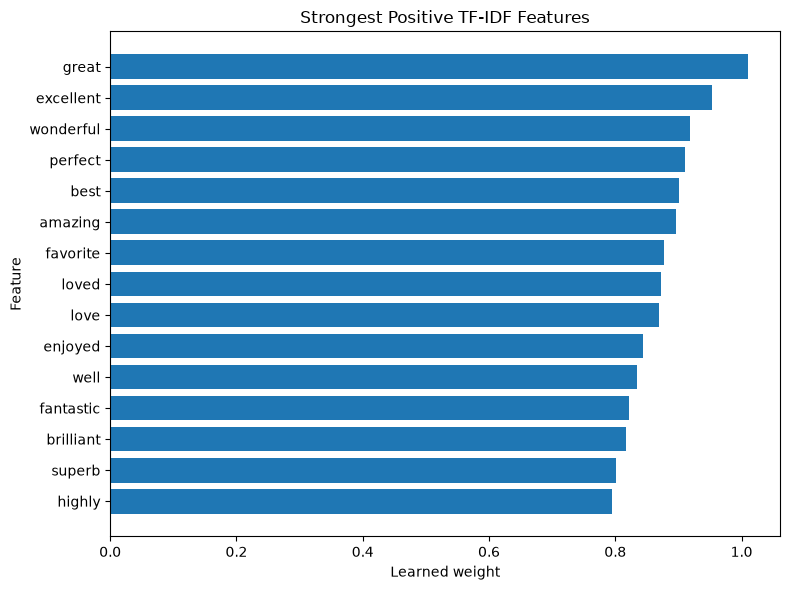

In [49]:
positive_plot_df = (
    top_positive_features
    .head(15)
    .sort_values(
        by="weight",
        ascending=True,
    )
)

plt.figure(
    figsize=(8, 6)
)

plt.barh(
    positive_plot_df[
        "feature"
    ],
    positive_plot_df[
        "weight"
    ],
)

plt.xlabel(
    "Learned weight"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Strongest Positive TF-IDF Features"
)

plt.tight_layout()

plt.show()

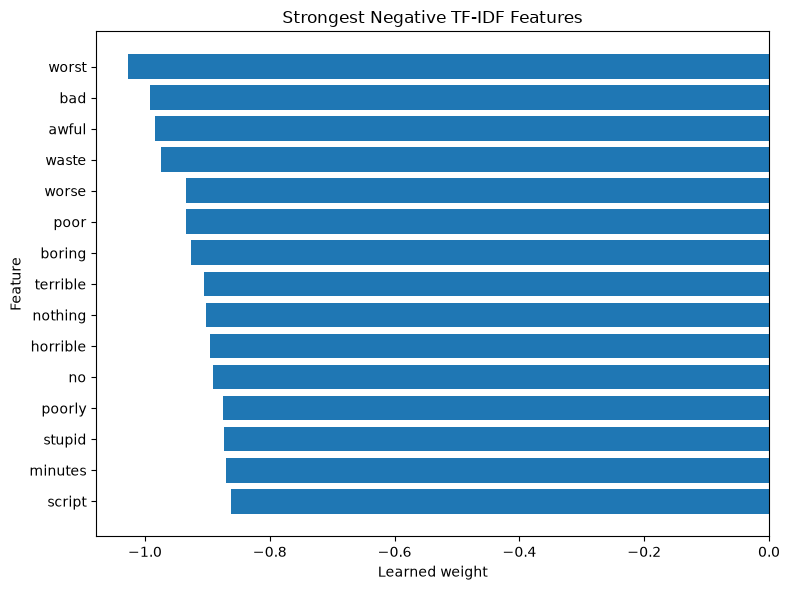

In [50]:
negative_plot_df = (
    top_negative_features
    .head(15)
    .sort_values(
        by="weight",
        ascending=False,
    )
)

plt.figure(
    figsize=(8, 6)
)

plt.barh(
    negative_plot_df[
        "feature"
    ],
    negative_plot_df[
        "weight"
    ],
)

plt.xlabel(
    "Learned weight"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Strongest Negative TF-IDF Features"
)

plt.tight_layout()

plt.show()

## 14. Explain individual predictions

For a linear model, each feature contributes directly to the final logit.

For one review:

feature contribution = TF-IDF value × learned model weight

Positive contributions push the prediction toward positive sentiment.

Negative contributions push the prediction toward negative sentiment.

In [53]:
def explain_review_prediction(
    review_text: str,
    vectorizer,
    model_weights: np.ndarray,
    model_bias: float,
    top_n: int = 10,
) -> pd.DataFrame:
    cleaned_text = clean_text_for_model(
        review_text
    )

    sparse_review = vectorizer.transform(
        [cleaned_text]
    )

    feature_indices = (
        sparse_review
        .nonzero()[1]
    )

    tfidf_values = (
        sparse_review[
            0,
            feature_indices
        ]
        .toarray()
        .reshape(-1)
    )

    review_features = feature_names[
        feature_indices
    ]

    review_weights = model_weights[
        feature_indices
    ]

    contributions = (
        tfidf_values
        * review_weights
    )

    explanation_df = pd.DataFrame(
        {
            "feature": review_features,
            "tfidf": tfidf_values,
            "weight": review_weights,
            "contribution": contributions,
        }
    )

    explanation_df[
        "absolute_contribution"
    ] = np.abs(
        explanation_df[
            "contribution"
        ]
    )

    explanation_df = (
        explanation_df
        .sort_values(
            by="absolute_contribution",
            ascending=False,
        )
        .head(top_n)
        .reset_index(drop=True)
    )

    return explanation_df

In [55]:
example_false_positive = (
    most_confident_false_positives
    .iloc[0]
)

print(
    "Actual label:",
    example_false_positive[
        "actual_label"
    ],
)

print(
    "Predicted label:",
    example_false_positive[
        "predicted_label"
    ],
)

print(
    "Positive probability:",
    f"{example_false_positive['positive_probability']:.4f}",
)

print()
print(
    example_false_positive["text"]
)

Actual label: neg
Predicted label: pos
Positive probability: 0.8079

Mickey Rourke hunts Diane Lane in Elmore Leonard's Killshot It is not like Mickey Rourke ever really disappeared. He has had a steady string of appearances before he burst back on the scene. He was memorable in: Domino, Sin City, Man on Fire, Once Upon a Time in Mexico, and Get Carter. But in his powerful dramatic performance in The Wrestler (2008), we see a full blown presentation of the character only hinted at in Get Carter. Whenever we get to know him, Rourke remains a cool, but sleazy, muscle bound slim ball.<br /><br />This is an Elmore Leonard story, and production. Leonard wrote such notable movies as taunt western thriller 3:10 to Yuma, Be Cool, Jackie Brown, Get Shorty, 52 Pick-Up, and Joe Kidd. This means that we get tough guys, some good, some not so good.<br /><br />It also means we get tight, realistic plots with characters doing what is best for them in each situation, weaving complications into violent

In [56]:
false_positive_explanation = (
    explain_review_prediction(
        review_text=example_false_positive[
            "text"
        ],
        vectorizer=vectorizer,
        model_weights=model_weights,
        model_bias=model_bias,
        top_n=15,
    )
)

false_positive_explanation

,feature,tfidf,weight,contribution,absolute_contribution
0,wonderful,0.072833,0.918606,0.066904,0.066904
1,powerful,0.091444,0.646840,0.059149,0.059149
2,performances,0.071051,0.679757,0.048297,0.048297
3,love,0.051454,0.868622,0.044694,0.044694
4,also,0.055125,0.787171,0.043393,0.043393
5,incredible,0.054849,0.668239,0.036653,0.036653
6,no,0.039871,-0.890277,-0.035497,0.035497
7,charming,0.056324,0.589331,0.033194,0.033194
8,hawke,0.079635,0.398480,0.031733,0.031733
9,intense,0.059984,0.525736,0.031536,0.031536


In [57]:
example_false_negative = (
    most_confident_false_negatives
    .iloc[0]
)

print(
    "Actual label:",
    example_false_negative[
        "actual_label"
    ],
)

print(
    "Predicted label:",
    example_false_negative[
        "predicted_label"
    ],
)

print(
    "Positive probability:",
    f"{example_false_negative['positive_probability']:.4f}",
)

print()
print(
    example_false_negative["text"]
)

Actual label: pos
Predicted label: neg
Positive probability: 0.1937

When the movie first started I thought cheesy. The first ten minutes were really boring. After the slow beginning and some of the soap opera antics, I started liking it. The plot was different than anything I had ever seen. Now, was it a horror? Not really. It shouldn't have been classied as a horror or the producers should have put more money into the movie to make it scary. As it was, the creatures where only there for a short time. I can only assume this was for money reason.<br /><br />The good side was that the movie was very entertaining. It held my interest (after the start) and did make me wonder about creatures from another dimension.<br /><br />It was obvious that this was a first time movie for the director, but there were a couple of highlights. By the end, I was hooked. Too bad Hollywood didn't put more money behind this.


In [58]:
review_text = (
    example_false_positive[
        "text"
    ]
)

cleaned_review = clean_text_for_model(
    review_text
)

review_vector = vectorizer.transform(
    [cleaned_review]
)

manual_logit = (
    review_vector
    .dot(model_weights)[0]
    + model_bias
)

manual_probability = (
    1.0
    / (
        1.0
        + np.exp(-manual_logit)
    )
)

print(
    "Manual logit:",
    manual_logit,
)

print(
    "Manual positive probability:",
    manual_probability,
)

Manual logit: 1.4364061
Manual positive probability: 0.8078975


In [59]:
stored_probability = (
    example_false_positive[
        "positive_probability"
    ]
)

print(
    "Stored probability:",
    stored_probability,
)

print(
    "Manual probability:",
    manual_probability,
)

print(
    "Probabilities match:",
    np.isclose(
        stored_probability,
        manual_probability,
        atol=1e-5,
    ),
)

Stored probability: 0.8078975
Manual probability: 0.8078975
Probabilities match: True


## 15. Save evaluation reports

We save the final test metrics, prediction results, error examples,
and model interpretation tables for later comparison.

In [61]:
results_df.to_csv(
    REPORT_DIR
    / "test_predictions.csv",
    index=False,
)

In [62]:
classification_report_df.to_csv(
    REPORT_DIR
    / "classification_report.csv"
)

confusion_matrix_df.to_csv(
    REPORT_DIR
    / "confusion_matrix.csv"
)

In [63]:
metrics_df = pd.DataFrame(
    {
        "metric": [
            "accuracy",
            "precision",
            "recall",
            "f1",
            "macro_f1",
            "reviews_per_second",
        ],
        "value": [
            test_accuracy,
            test_precision,
            test_recall,
            test_f1,
            test_macro_f1,
            reviews_per_second,
        ],
    }
)

metrics_df.to_csv(
    REPORT_DIR / "test_metrics.csv",
    index=False,
)


In [64]:
false_positives_df.to_csv(
    REPORT_DIR
    / "false_positives.csv",
    index=False,
)

false_negatives_df.to_csv(
    REPORT_DIR
    / "false_negatives.csv",
    index=False,
)

In [65]:
feature_weight_df.to_csv(
    REPORT_DIR
    / "feature_weights.csv",
    index=False,
)

top_features_comparison.to_csv(
    REPORT_DIR
    / "top_sentiment_features.csv",
    index=False,
)

In [66]:
length_group_analysis.to_csv(
    REPORT_DIR
    / "error_by_review_length.csv",
    index=False,
)

In [67]:
saved_report_files = sorted(
    REPORT_DIR.glob("*.csv")
)

print(
    "Saved reports:"
)

for report_file in saved_report_files:
    print(
        "-",
        report_file.name,
    )

Saved reports:
- classification_report.csv
- confusion_matrix.csv
- error_by_review_length.csv
- false_negatives.csv
- false_positives.csv
- feature_weights.csv
- test_metrics.csv
- test_predictions.csv
- top_sentiment_features.csv
